数据总量：755,525 行
列名： ['user_id', 'goods_id', 'category_id', 'behavior', 'timestamp', 'sex', 'address', 'device', 'price', 'amount', 'comment', 'dt', 'date', 'hour', 'is_high_freq', 'category_label', 'category_count', '品类商品数', '大类']

前3行数据预览：
   user_id  goods_id  category_id behavior   timestamp  sex address device  \
0   866796   5002615      2520377       pv  1716991385    0      成都  Redmi   
1   866796   2734026      4145813       pv  1716994184    0      成都  Redmi   
2   866796   5002615      2520377       pv  1716996273    0      成都  Redmi   

   price  amount comment               dt       date  hour  is_high_freq  \
0    0.0       0     无评论  2024/5/29 14:03  2024/5/29    14             0   
1    0.0       0     无评论  2024/5/29 14:49  2024/5/29    14             0   
2    0.0       0     无评论  2024/5/29 15:24  2024/5/29    15             0   

  category_label  category_count  品类商品数    大类  
0          LED台灯           17985   8065  数码配件  
1            数据线           28497   9701  数码配件 

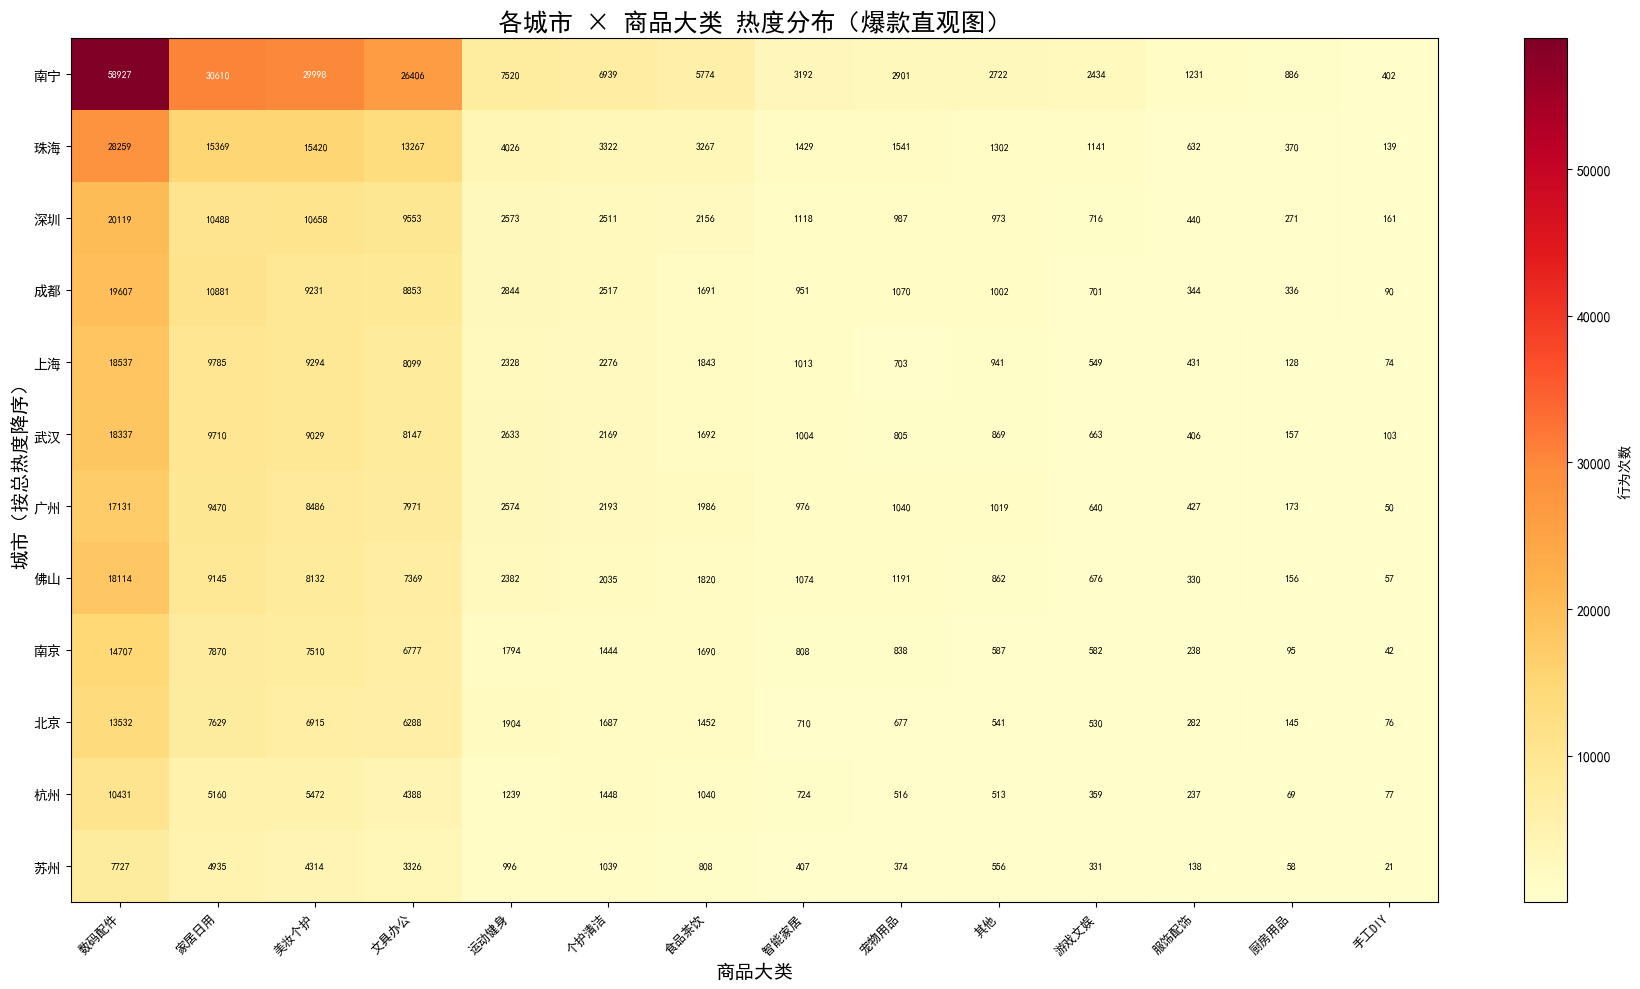


四分位数：Q1(25%)=44328, Q2(50%)=54930, Q3(75%)=60770

按四分位数分组：
南宁: 179,942 → Q4 (第一梯队 / 高活跃)
珠海: 89,484 → Q4 (第一梯队 / 高活跃)
深圳: 62,724 → Q4 (第一梯队 / 高活跃)
成都: 60,118 → Q3 (第二梯队 / 中高活跃)
上海: 56,001 → Q3 (第二梯队 / 中高活跃)
武汉: 55,724 → Q3 (第二梯队 / 中高活跃)
广州: 54,136 → Q2 (第三梯队 / 中低活跃)
佛山: 53,343 → Q2 (第三梯队 / 中低活跃)
南京: 44,982 → Q2 (第三梯队 / 中低活跃)
北京: 42,368 → Q1 (第四梯队 / 低活跃)
杭州: 31,673 → Q1 (第四梯队 / 低活跃)
苏州: 25,030 → Q1 (第四梯队 / 低活跃)


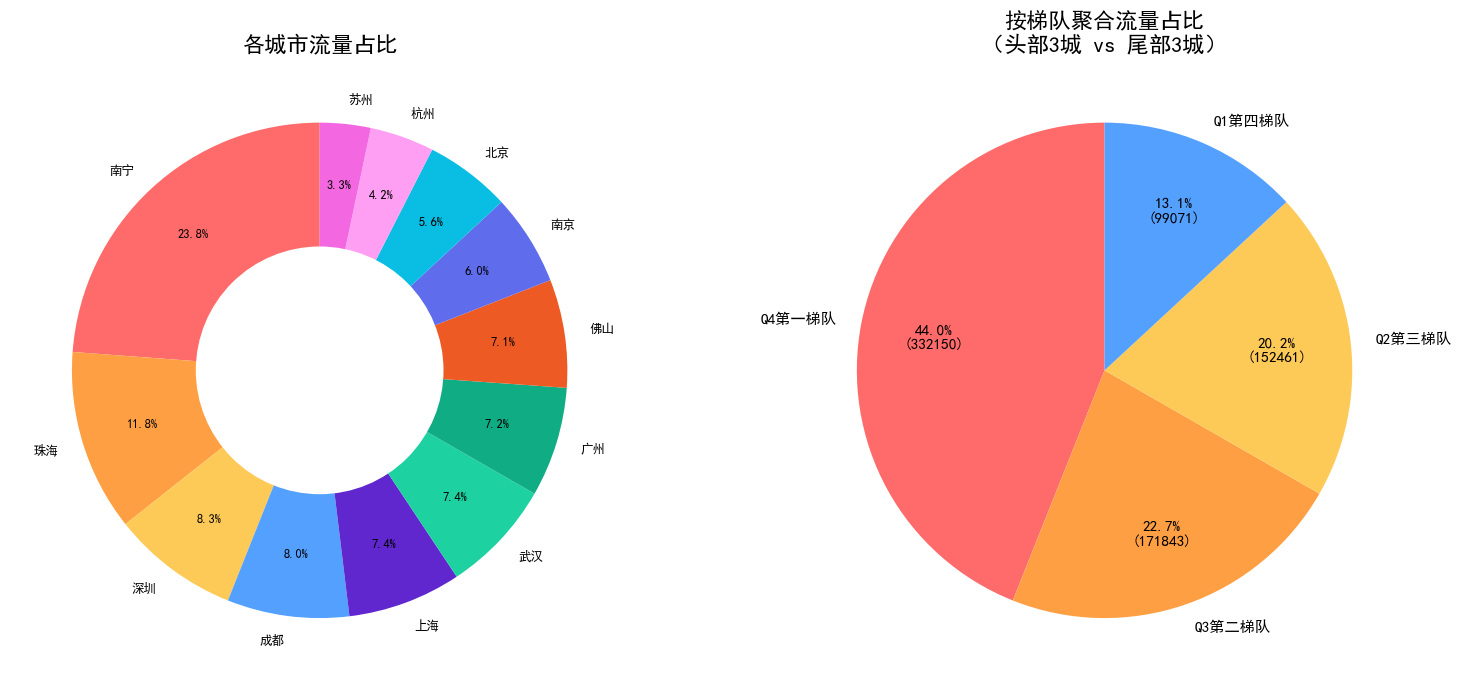


各城市三大核心品类占比明细：
大类       三大占比  长尾占比
address            
苏州       67.8  32.2
上海       67.2  32.8
南京       66.9  33.1
武汉       66.5  33.5
杭州       66.5  33.5
南宁       66.4  33.6
北京       66.3  33.7
佛山       66.3  33.7
成都       66.1  33.9
珠海       66.0  34.0
深圳       65.8  34.2
广州       64.8  35.2


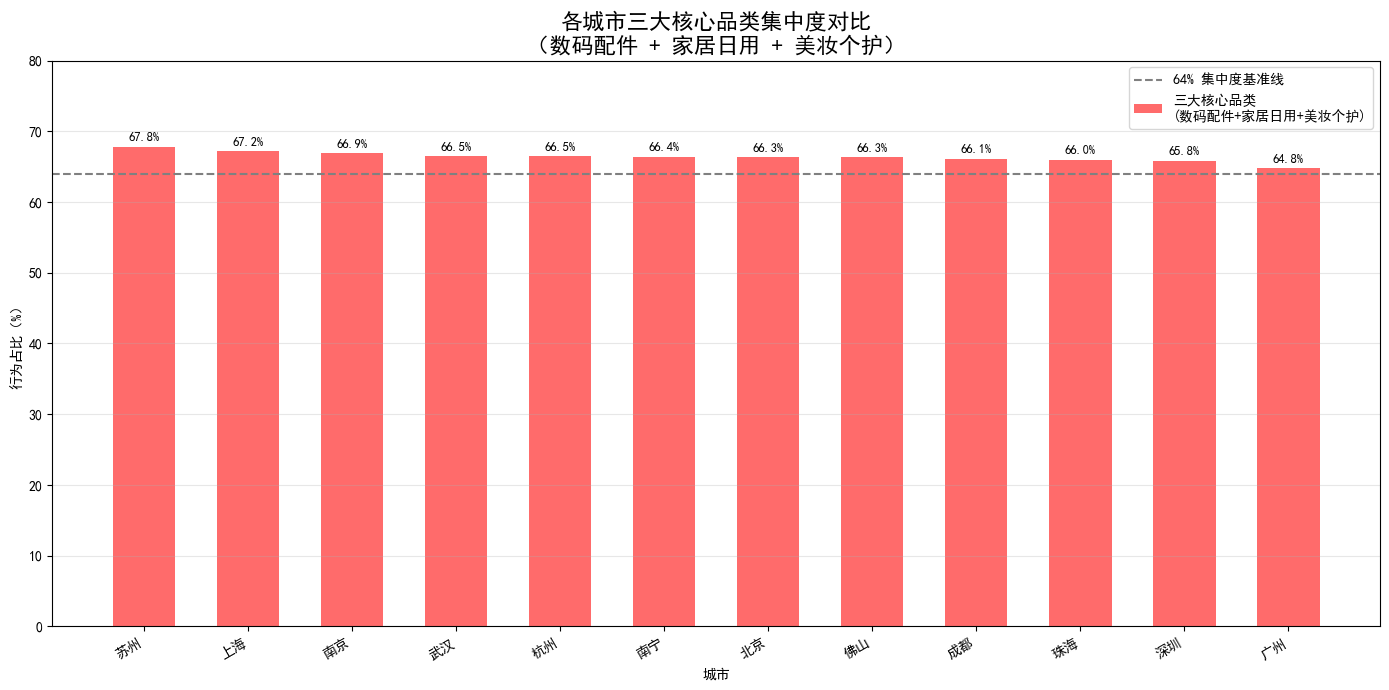

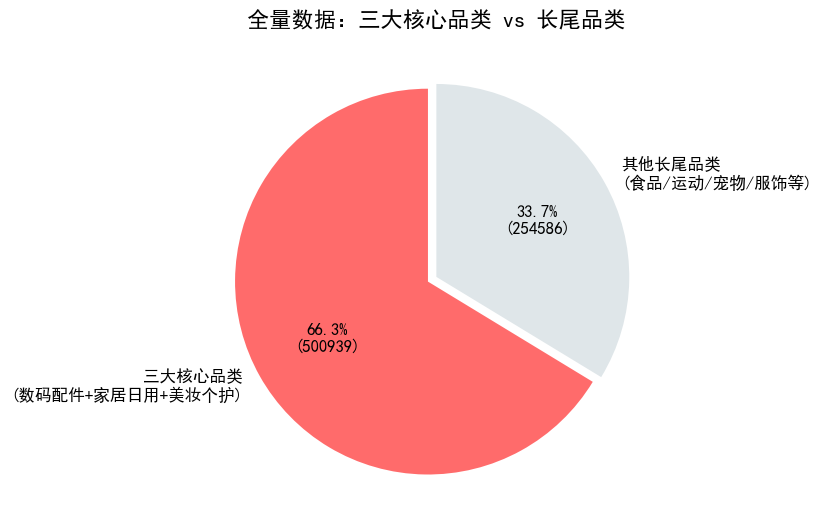


核心发现：
  全量数据中，三大核心品类合计占比：66.3%
  长尾品类合计占比：33.7%
  各城市三大核心品类占比范围：64.8% ~ 67.8%，全部超过64%

雷达图底层归一化数据（Top5城市 × 全品类）
大类           数码配件      家居日用      美妆个护      文具办公      运动健身      个护清洁      食品茶饮  \
address                                                                         
南宁       1.000000  0.518852  0.508453  0.447420  0.126519  0.116647  0.096851   
珠海       0.478905  0.259885  0.260751  0.224169  0.067150  0.055188  0.054254   
深圳       0.340594  0.176949  0.179838  0.161062  0.042462  0.041408  0.035376   
成都       0.331895  0.183627  0.155591  0.149168  0.047066  0.041510  0.027475   
上海       0.313714  0.165004  0.156662  0.136357  0.038299  0.037415  0.030058   

大类           智能家居      宠物用品        其他      游戏文娱      服饰配饰      厨房用品     手工DIY  
address                                                                        
南宁       0.052979  0.048035  0.044993  0.040100  0.019659  0.013797  0.005573  
珠海       0.023023  0.024927  0.020866  0.018130  0.009481  0.005029  0.001104  

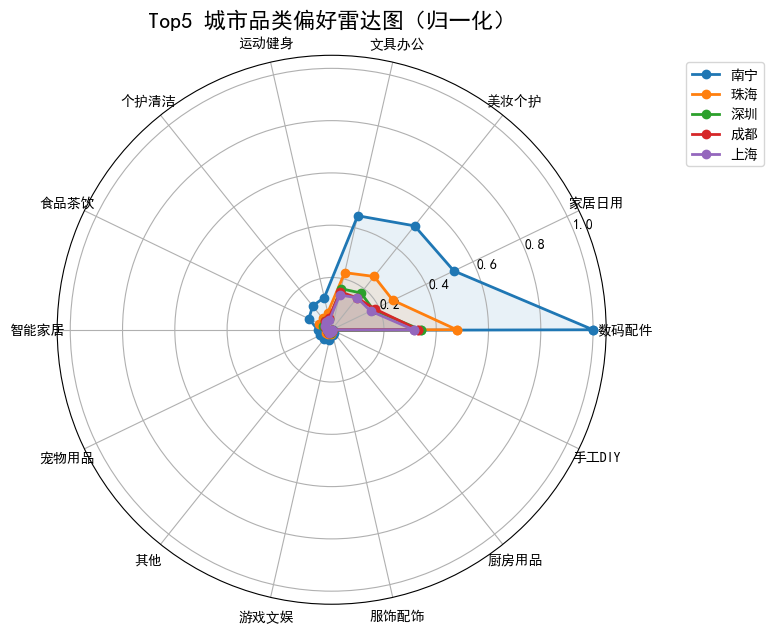


✅ 全部图表生成完成！


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================== 1. 设置中文字体 ====================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 2. 加载数据 ====================
df = pd.read_csv("D:/桌面/地域数据.csv") 

# ==================== 3. 数据概览 ====================
print("数据总量：{:,} 行".format(len(df)))
print("列名：", df.columns.tolist())
print("\n前3行数据预览：")
print(df.head(3))
print("\n各城市用户数（即总行为次数）：")
print(df['address'].value_counts().head(10))

# ==================== 4. 按城市+大类汇总行为次数 ====================
heatmap_data = df.groupby(['address', '大类']).size().reset_index(name='行为次数')
pivot = heatmap_data.pivot(index='address', columns='大类', values='行为次数').fillna(0)

# 按城市总热度排序
city_total = pivot.sum(axis=1).sort_values(ascending=False)
pivot = pivot.loc[city_total.index]
# 按品类总热度排序
category_total = pivot.sum(axis=0).sort_values(ascending=False)
pivot = pivot[category_total.index]

# ==================== 5. 输出汇总统计 ====================
print("\n" + "="*60)
print("各城市总行为次数（从高到低）")
print("="*60)
print(city_total.to_string())
print("="*60)
print(f"合计：{city_total.sum():,} 次行为")
print("="*60)

print("\n各城市最热门的Top3品类：")
for city in pivot.index:
    top3 = pivot.loc[city].nlargest(3)
    print(f"\n{city}:")
    for cat, val in top3.items():
        print(f"  {cat}: {val:,} 次行为")

# ==================== 6. 热力图（全量城市 × 全量品类） ====================
fig, ax = plt.subplots(figsize=(18, 10))
heatmap = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(pivot.index, fontsize=10)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        value = pivot.iloc[i, j]
        if value > 0:
            color = 'white' if value > pivot.values.max() * 0.5 else 'black'
            ax.text(j, i, f'{value:.0f}', ha='center', va='center', color=color, fontsize=7)

plt.colorbar(heatmap, label='行为次数')
plt.title('各城市 × 商品大类 热度分布（爆款直观图）', fontsize=18)
plt.xlabel('商品大类', fontsize=14)
plt.ylabel('城市（按总热度降序）', fontsize=14)
plt.tight_layout()
plt.show()

# ==================== 7. 四分位数分组 ====================
Q1 = city_total.quantile(0.25)
Q2 = city_total.quantile(0.50)
Q3 = city_total.quantile(0.75)
print(f"\n四分位数：Q1(25%)={Q1:.0f}, Q2(50%)={Q2:.0f}, Q3(75%)={Q3:.0f}")
print("\n按四分位数分组：")
for city, value in city_total.items():
    if value >= Q3:
        group = "Q4 (第一梯队 / 高活跃)"
    elif value >= Q2:
        group = "Q3 (第二梯队 / 中高活跃)"
    elif value >= Q1:
        group = "Q2 (第三梯队 / 中低活跃)"
    else:
        group = "Q1 (第四梯队 / 低活跃)"
    print(f"{city}: {value:,} → {group}")

# ==================== 8. 流量占比图（各城市饼图 + 梯队聚合饼图） ====================
city_df = pd.DataFrame({
    '城市': city_total.index,
    '总行为次数': city_total.values
})
tier_map = {
    '南宁': 'Q4第一梯队', '珠海': 'Q4第一梯队', '深圳': 'Q4第一梯队',
    '成都': 'Q3第二梯队', '上海': 'Q3第二梯队', '武汉': 'Q3第二梯队',
    '广州': 'Q2第三梯队', '佛山': 'Q2第三梯队', '南京': 'Q2第三梯队',
    '北京': 'Q1第四梯队', '杭州': 'Q1第四梯队', '苏州': 'Q1第四梯队'
}
city_df['梯队'] = city_df['城市'].map(tier_map)
tier_df = city_df.groupby('梯队')['总行为次数'].sum().reset_index()
tier_order = ['Q4第一梯队', 'Q3第二梯队', 'Q2第三梯队', 'Q1第四梯队']
tier_df['梯队'] = pd.Categorical(tier_df['梯队'], categories=tier_order, ordered=True)
tier_df = tier_df.sort_values('梯队')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors_city = ['#FF6B6B', '#FF9F43', '#FECA57', '#54A0FF', '#5F27CD', '#1DD1A1',
               '#10AC84', '#EE5A24', '#5F6DEC', '#0ABDE3', '#FF9FF3', '#F368E0']
wedges, texts, autotexts = axes[0].pie(
    city_df['总行为次数'], labels=city_df['城市'],
    autopct=lambda pct: f'{pct:.1f}%', colors=colors_city,
    startangle=90, pctdistance=0.75, textprops={'fontsize': 9}
)
centre_circle = plt.Circle((0, 0), 0.50, fc='white', linewidth=0)
axes[0].add_artist(centre_circle)
axes[0].set_title('各城市流量占比', fontsize=16)

tier_colors = ['#FF6B6B', '#FF9F43', '#FECA57', '#54A0FF']
wedges2, texts2, autotexts2 = axes[1].pie(
    tier_df['总行为次数'], labels=tier_df['梯队'],
    autopct=lambda pct: f'{pct:.1f}%\n({pct/100 * tier_df["总行为次数"].sum():.0f})',
    colors=tier_colors, startangle=90, pctdistance=0.70, textprops={'fontsize': 11}
)
axes[1].set_title('按梯队聚合流量占比\n（头部3城 vs 尾部3城）', fontsize=16)
plt.tight_layout()
plt.show()

# ==================== 9. 三大核心品类集中度分析====================
top3_cats = category_total.head(3).index.tolist()
df_top3 = pivot[top3_cats].copy()

df_top3['三大合计'] = df_top3[top3_cats].sum(axis=1)
df_top3['总行为'] = city_total

df_top3['三大占比'] = (df_top3['三大合计'] / df_top3['总行为'] * 100).round(1)
df_top3['长尾占比'] = (100 - df_top3['三大占比']).round(1)
df_top3 = df_top3.sort_values('三大占比', ascending=False)

print("\n各城市三大核心品类占比明细：")
print(df_top3[['三大占比', '长尾占比']].to_string())

# 柱状图
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_top3))
bars = ax.bar(x, df_top3['三大占比'], width=0.6, color='#FF6B6B',
              label='三大核心品类\n(数码配件+家居日用+美妆个护)')
for bar, pct in zip(bars, df_top3['三大占比']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(y=64, color='gray', linestyle='--', linewidth=1.5, label='64% 集中度基准线')
ax.set_xticks(x)
ax.set_xticklabels(df_top3.index, rotation=30, ha='right')
ax.set_ylabel('行为占比（%）')
ax.set_xlabel('城市')
ax.set_title('各城市三大核心品类集中度对比\n（数码配件 + 家居日用 + 美妆个护）', fontsize=16)
ax.set_ylim(0, 80)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 全量数据饼图
total_all = city_total.sum()
total_top3 = df_top3['三大合计'].sum()
total_others = total_all - total_top3

if total_others < 0:
    print(f"⚠️ 警告：total_others={total_others}，被强制置为0，请检查数据！")
    total_others = 0

fig2, ax2 = plt.subplots(figsize=(8, 8))
labels = ['三大核心品类\n(数码配件+家居日用+美妆个护)', '其他长尾品类\n(食品/运动/宠物/服饰等)']
sizes = [total_top3, total_others]
colors = ['#FF6B6B', '#DFE6E9']
explode = (0.05, 0)
wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n({pct/100 * total_all:.0f})',
    colors=colors, explode=explode, startangle=90, textprops={'fontsize': 12}
)
ax2.set_title('全量数据：三大核心品类 vs 长尾品类', fontsize=16)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("核心发现：")
print(f"  全量数据中，三大核心品类合计占比：{total_top3/total_all*100:.1f}%")
print(f"  长尾品类合计占比：{total_others/total_all*100:.1f}%")
print(f"  各城市三大核心品类占比范围：{df_top3['三大占比'].min()}% ~ {df_top3['三大占比'].max()}%，全部超过64%")
print("="*60)

# ==================== 10. 雷达图（Top5城市品类结构对比） ====================
top5_cities = city_total.head(5).index.tolist()
pivot_top5 = pivot.loc[top5_cities]
min_val = pivot_top5.min().min()
max_val = pivot_top5.max().max()
pivot_norm = (pivot_top5 - min_val) / (max_val - min_val) if max_val > min_val else pivot_top5

# 打印雷达图底层归一化数据
print("\n" + "="*60)
print("雷达图底层归一化数据（Top5城市 × 全品类）")
print("="*60)
print(pivot_norm)
print("="*60)

# 绘制雷达图
categories = pivot_top5.columns.tolist()
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig3 = plt.figure(figsize=(8, 8))
ax3 = fig3.add_subplot(111, polar=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, city in enumerate(top5_cities):
    values = pivot_norm.loc[city].values.flatten().tolist()
    values += values[:1]
    ax3.plot(angles, values, 'o-', linewidth=2, label=city, color=colors[i])
    ax3.fill(angles, values, alpha=0.1, color=colors[i])
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories, fontsize=10)
ax3.set_title('Top5 城市品类偏好雷达图（归一化）', fontsize=16, pad=20)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

print("\n✅ 全部图表生成完成！")